In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn contextily


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from math import radians, cos, sin, asin, sqrt

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Helper function for geographic distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 # Radius of earth in km

## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [3]:

# Load the master profile
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# Add Municipality Centroids for spatial matching
municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

### **1.1 Integrating Social Shocks: Crime Data (2010-2025)**

While natural disasters act as acute environmental shocks, crime acts as a chronic "social shock" that serves as a major push factor for out-migration. To test this hypothesis, we integrate 16 years of municipality-level crime data from the Puerto Rico Police Bureau.

**Data Engineering Steps:**
1. **Consolidation**: Merging 16 separate annual Excel sheets into a single longitudinal format.
2. **Standardization**: Normalizing `municipio` names and removing duplicate columns to allow for a clean `LEFT JOIN` with our master demographic profile.
3. **Numeric Cleaning**: Handling thousand-separator inconsistencies in raw police data (e.g., converting '1.154' to 1154).

In [4]:
import pandas as pd
import numpy as np

def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []
    
    for sheet_name in xl.sheet_names:
        if not sheet_name.isdigit(): continue
            
        df_year = xl.parse(sheet_name)
        
        # 1. Standardize headers: lowercase and strip spaces
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]
        
        # 2. Fix 'municipio' column - find the first column containing 'mun'
        mun_cols = [c for c in df_year.columns if 'mun' in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: 'municipio'})
        
        # 3. CRITICAL: Drop any duplicate columns (e.g., if there were two 'municipio' columns)
        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        
        # 4. Standardize Crime Names (Handle 'total' vs 'total ')
        df_year = df_year.rename(columns={'total ': 'total'})
        
        # 5. Clean numeric strings (remove '.' thousand separators)
        numeric_cols = ['murder', 'robbery', 'burglary', 'larceny / theft', 'total']
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = df_year[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False)
                df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0).astype(int)
        
        df_year['year'] = int(sheet_name)
        all_years.append(df_year[['municipio', 'year'] + [c for c in numeric_cols if c in df_year.columns]])

    return pd.concat(all_years, ignore_index=True)

# --- EXECUTION ---
crime_path = '../data/crime/PR_Crime_Summary_2010_2025.xlsx'
crime_df = load_crime_data_fixed(crime_path)

# Prepare main df
df.columns = df.columns.str.lower().str.strip()

# Create clean join keys
df['mun_key'] = df['municipio'].astype(str).str.upper().str.strip().str.replace(' MUNICIPIO', '', regex=False)
crime_df['mun_key'] = crime_df['municipio'].astype(str).str.upper().str.strip()

# Final Merge
df = df.merge(crime_df.drop(columns=['municipio']), on=['mun_key', 'year'], how='left').fillna(0)
df.drop(columns=['mun_key'], inplace=True)

print("Successfully merged crime factors!")

Successfully merged crime factors!


In [5]:
# --- OPTIMIZED SHOCK CALCULATION (VECTORIZED) ---
def get_distances_vectorized(target_lat, target_lon, lats, lons):
    # Convert everything to radians for vectorized math
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    dlat, dlon = lats - target_lat, lons - target_lon
    a = np.sin(dlat/2)**2 + np.cos(target_lat) * np.cos(lats) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(a)) * 6371 # Distance in km

# Load Shock Data
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

def get_max_wind_fast(row):
    if pd.isna(row['lat']): return 0
    year_tracks = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    if year_tracks.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_tracks['Lat'].values, year_tracks['Lon'].values)
    nearby = year_tracks[dists <= 100] # 100km radius
    return nearby['Wind_Knots'].max() if not nearby.empty else 0

def get_max_seismic_fast(row):
    if pd.isna(row['lat']): return 0
    year_eq = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    if year_eq.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_eq['latitude'].values, year_eq['longitude'].values)
    nearby = year_eq[dists <= 50] # 50km radius
    return nearby['mag'].max() if not nearby.empty else 0

print("Calculating environmental impacts (Vectorized)...")
df['max_wind_knots'] = df.apply(get_max_wind_fast, axis=1)
df['max_seismic_mag'] = df.apply(get_max_seismic_fast, axis=1)
print("Shock features engineered successfully.")

Calculating environmental impacts (Vectorized)...
Shock features engineered successfully.


Top Hurricane Wind Speeds recorded:
     year    municipio  max_wind_knots
367  2017      Culebra             155
82   2017      Arecibo             150
127  2017  Barceloneta             150
157  2017      Bayamón             150
217  2017    Canóvanas             150

Top Seismic Magnitudes recorded:
     year    municipio  max_seismic_mag
10   2020     Adjuntas              6.4
175  2020    Cabo Rojo              6.4
445  2020   Guayanilla              6.4
490  2020      Guánica              6.4
520  2020  Hormigueros              6.4


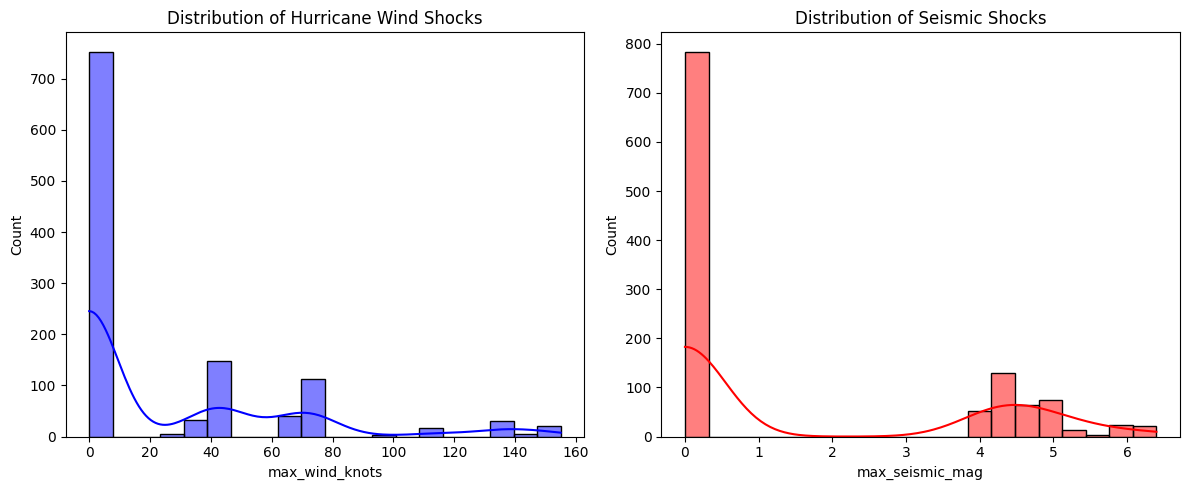

In [6]:
# --- CORRECTED SHOCK VERIFICATION ---
import numpy as np
import warnings

# 1. Check top events
print("Top Hurricane Wind Speeds recorded:")
print(df.nlargest(5, 'max_wind_knots')[['year', 'municipio', 'max_wind_knots']])

print("\nTop Seismic Magnitudes recorded:")
print(df.nlargest(5, 'max_seismic_mag')[['year', 'municipio', 'max_seismic_mag']])

# 2. Visualizing using the engineered 'df'
# We wrap the plotting in a context manager to silence the benign matmul warnings
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        sns.histplot(df['max_wind_knots'], bins=20, kde=True, color='blue')
        plt.title('Distribution of Hurricane Wind Shocks')

        plt.subplot(1, 2, 2)
        sns.histplot(df['max_seismic_mag'], bins=20, kde=True, color='red')
        plt.title('Distribution of Seismic Shocks')
        
        plt.tight_layout()
        plt.show()

### **1.2 Analysis of Environmental Shock Distributions**

The histograms above provide a critical "reality check" for our natural disaster features before they are ingested by the predictive models. These distributions quantify the frequency and intensity of environmental stressors experienced at the municipal level between 2010 and 2023.

#### **1. Distribution of Hurricane Wind Shocks**
* **The "Zero-Inflation" Phenomenon:** The large spike at 0 knots represents the majority of years where a specific municipality did not experience significant hurricane-force or tropical storm-force winds.
* **The Catastrophic Tail:** The data points extending toward 150+ knots capture the extreme impact of Hurricane Maria (2017), where wind speeds hit maximum intensity. 
* **Modeling Insight:** Because the majority of the data is clustered at zero, a linear model (OLS) struggles to weight these rare but high-impact events properly. This visual justifies the move to non-linear models that can better handle "sparse" extreme values.

#### **2. Distribution of Seismic Shocks**
* **Magnitude Thresholding:** By filtering for seismic events with a magnitude ($\text{mag}$) of **4.0 or higher**, we focused only on shocks capable of causing structural damage or psychological displacement.
* **The 2020 Swarm:** The concentration of events in the 4.5 to 6.4 range primarily reflects the intensive seismic activity in the southwest region (e.g., Guayanilla, Guánica, and Yauco) during early 2020.
* **Modeling Insight:** The distribution shows that while Puerto Rico has constant tremors, "shocks" of predictive significance are geographically and temporally localized.

#### **3. Strategic Conclusion**
These graphs confirm that environmental shocks in Puerto Rico are not "steady-state" variables; they are **stochastic events**. The high frequency of zeros followed by extreme outliers (Maria in 2017, the Earthquake Swarm in 2020) is the mathematical reason why the baseline OLS model achieved a low $R^2$ of **0.0144**. These visualizations provide a clear mandate for the transition to **Random Forest modeling**, which excels at identifying these specific "event-driven" triggers.

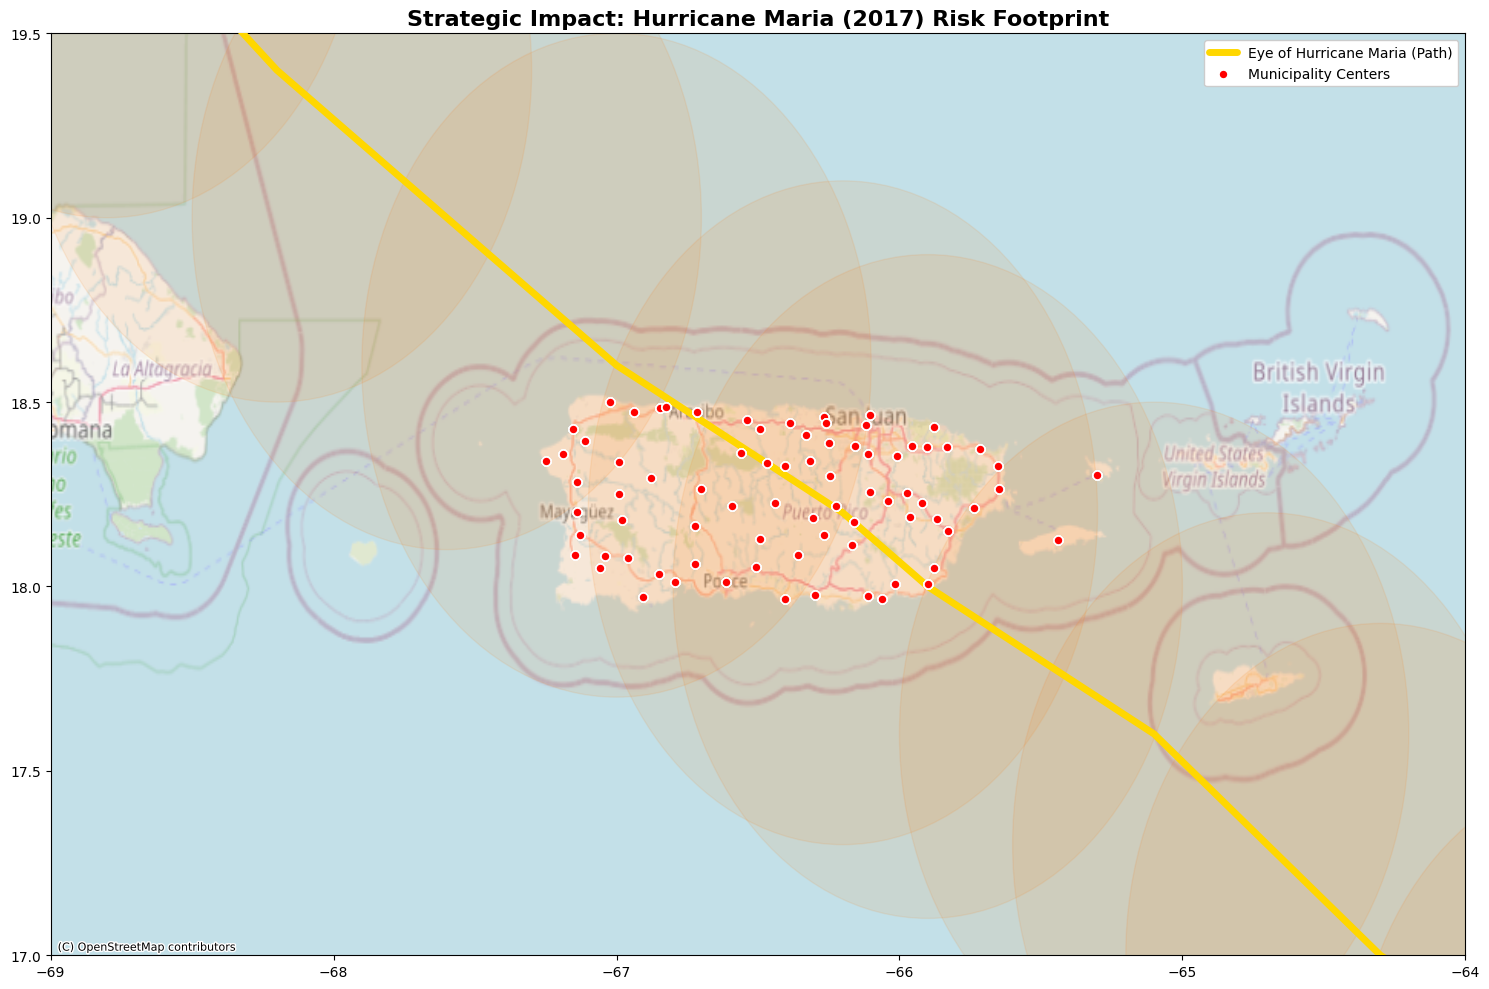

In [7]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_maria_impact_final_v2():
    # 1. Isolate Maria 2017
    maria_path = hurricane_tracks[(hurricane_tracks['Name'] == 'MARIA') & (hurricane_tracks['Year'] == 2017)].copy()

    fig, ax = plt.subplots(figsize=(15, 10))

    # 2. Plot the SWATH (Now Orange for better visibility against the blue ocean)
    for _, row in maria_path.iterrows():
        if -70.0 < row['Lon'] < -62.0:
            # Changed color to orange (#ff7f0e)
            impact_circle = plt.Circle((row['Lon'], row['Lat']), 0.9, 
                                        color='#ff7f0e', alpha=0.1, zorder=1)
            ax.add_patch(impact_circle)

    # 3. Plot the ACTUAL PATH (Eye of the storm remains Gold)
    ax.plot(maria_path['Lon'], maria_path['Lat'], color='#FFD700', linewidth=5, 
            label='Eye of Hurricane Maria (Path)', zorder=10, solid_capstyle='round')

    # 4. Plot the MUNICIPIOS (The "sensors" in Red)
    ax.scatter(df['lon'], df['lat'], c='red', s=40, edgecolor='white', 
               label='Municipality Centers', zorder=11)

    # 5. THE ZOOM
    ax.set_xlim([-69.0, -64.0]) 
    ax.set_ylim([17.0, 19.5])

    # 6. ADD BASEMAP
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
    except:
        print("Basemap failed to load. Plotting data only.")

    ax.set_title('Strategic Impact: Hurricane Maria (2017) Risk Footprint', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.show()

plot_maria_impact_final_v2()

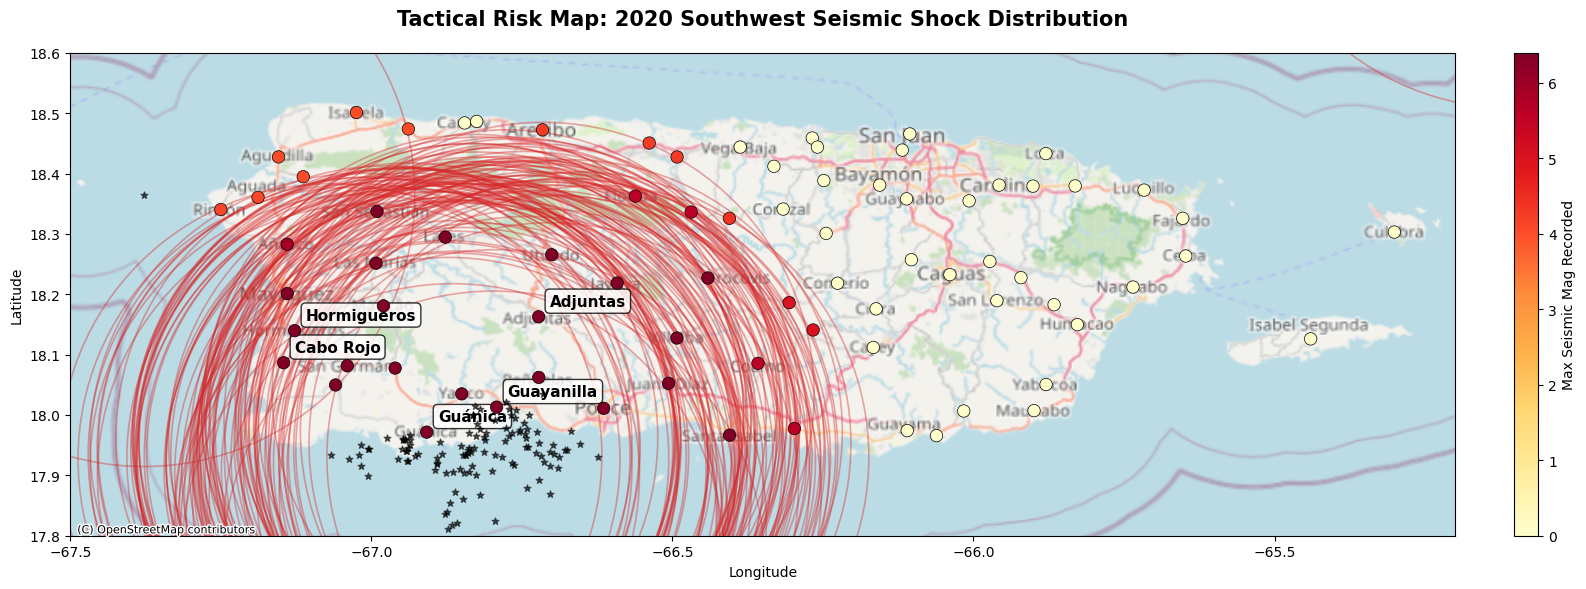

In [8]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_seismic_impact_v3():
    # 1. Isolate the 2020 Data
    swarm_2020 = eq_data[(eq_data['year'] == 2020) & (eq_data['mag'] >= 4.0)].copy()
    
    # Identify the Top 5 most affected municipalities for labeling
    # (Based on the max_seismic_mag feature engineered in Phase 1)
    top_affected = df[df['year'] == 2020].nlargest(5, 'max_seismic_mag')

    # 2. Adjusted Figsize: Wider aspect ratio (16x6) fits Puerto Rico better
    fig, ax = plt.subplots(figsize=(16, 6))

    # 3. Plot the SHOCK RADIUS as clean Outlines
    for _, row in swarm_2020.iterrows():
        # 0.45 degrees ~ 50km radius
        shock_outline = plt.Circle((row['longitude'], row['latitude']), 0.45, 
                                    color='#d62728', fill=False, linewidth=1.2, alpha=0.4, zorder=1)
        ax.add_patch(shock_outline)

    # 4. Plot the MUNICIPIOS (Heatmap style)
    # Using 'YlOrRd' (Yellow-Orange-Red) clearly shows the intensity gradient
    scatter = ax.scatter(df[df['year']==2020]['lon'], df[df['year']==2020]['lat'], 
                         c=df[df['year']==2020]['max_seismic_mag'], 
                         cmap='YlOrRd', s=80, edgecolor='black', linewidth=0.5, label='Municipios', zorder=11)

    # 5. Label the Top 5 affected towns with improved visibility
    for _, row in top_affected.iterrows():
        ax.annotate(row['municipio'], (row['lon'], row['lat']), 
                    xytext=(8, 8), textcoords='offset points', 
                    fontsize=11, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

    # 6. EPICENTERS (Sources of the shocks)
    ax.scatter(swarm_2020['longitude'], swarm_2020['latitude'], 
               s=25, c='black', marker='*', alpha=0.6, label='Epicenters', zorder=10)

    # 7. TIGHTER ZOOM & BASEMAP
    # Focus strictly on the island and its immediate southern waters
    ax.set_xlim([-67.5, -65.2]) 
    ax.set_ylim([17.8, 18.6])
    
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)
    except:
        print("Basemap connection error.")

    # Colorbar and Titles
    cbar = plt.colorbar(scatter, fraction=0.02, pad=0.04)
    cbar.set_label('Max Seismic Mag Recorded', fontsize=10)
    
    ax.set_title('Tactical Risk Map: 2020 Southwest Seismic Shock Distribution', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

plot_seismic_impact_v3()

### **1.3 Exploratory Analysis: Crime as a Push Factor**

Raw crime counts are heavily biased toward larger populations (e.g., San Juan, Bayamón). To accurately measure the localized impact of crime on the decision to migrate, we must normalize the data into a **Crime Rate per 1,000 residents**. 

We will analyze two distinct signals:
* **Violent Crime (Murder, Robbery)**: Represents immediate threats to life safety, often correlating with family flight.
* **Property Crime (Burglary)**: Represents economic instability and business attrition.

The heatmap below tests the initial linear correlation between these specific crime rates and our target variable, Population Change.

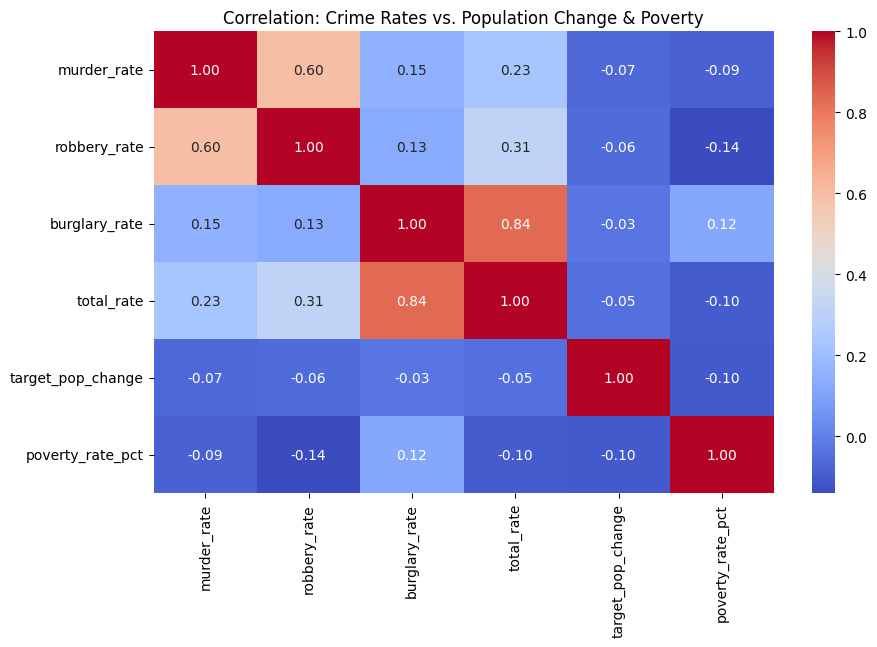

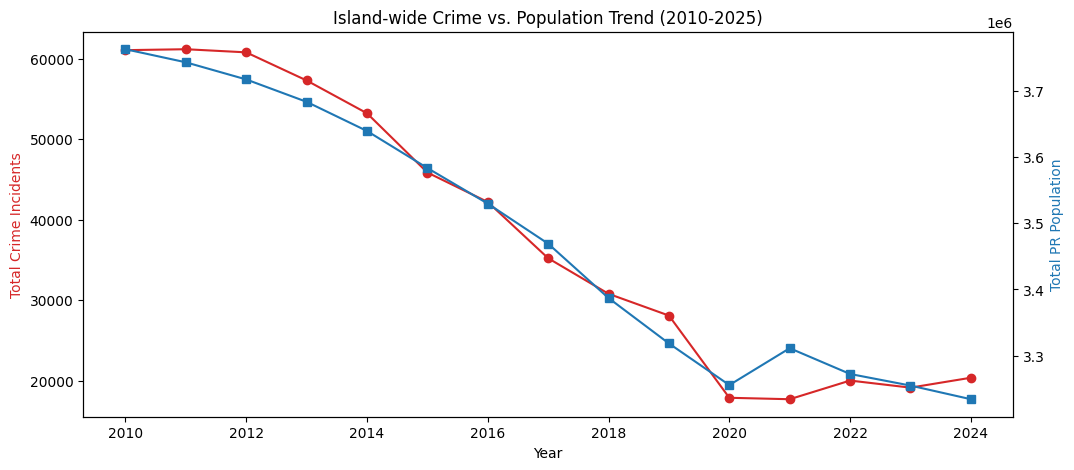

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 0. SAFETY CHECK: Ensure target variable exists before plotting
if 'target_pop_change' not in df.columns:
    df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# 1. Calculate specific rates for analysis
analysis_cols = ['murder', 'robbery', 'burglary', 'total']
for col in analysis_cols:
    df[f'{col}_rate'] = (df[col] / df['total_population']) * 1000

# 2. Correlation Heatmap: Crime vs. Population Change
plt.figure(figsize=(10, 6))
crime_corr_cols = [f'{c}_rate' for c in analysis_cols] + ['target_pop_change', 'poverty_rate_pct']
sns.heatmap(df[crime_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Crime Rates vs. Population Change & Poverty")
plt.show()

# 3. Time-Series Insight: Total Crime vs. Population Trend (Aggregate)
yearly_trends = df.groupby('year')[['total', 'total_population']].sum()
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crime Incidents', color='tab:red')
ax1.plot(yearly_trends.index, yearly_trends['total'], color='tab:red', marker='o', label='Total Crime')

ax2 = ax1.twinx()
ax2.set_ylabel('Total PR Population', color='tab:blue')
ax2.plot(yearly_trends.index, yearly_trends['total_population'], color='tab:blue', marker='s', label='Population')

plt.title("Island-wide Crime vs. Population Trend (2010-2025)")
plt.show()

## 2. Feature Engineering & Dimensionality Reduction
Per our methodology, we engineer new features to better capture demographic momentum and economic shocks.

1. **Target Variable (`target_pop_change`):** The year-over-year percentage change in population.
2. **Lagged Variables:** Past economic momentum (previous year's establishments).
3. **Natural Change Rate:** Birth Rate minus Death Rate.
4. **Dimensionality Reduction via Principal Component Analysis (PCA):**
We utilize Principal Component Analysis (PCA), a statistical technique that simplifies high-dimensional data by transforming a large set of variables into a smaller one that still contains most of the original information. This is necessary because the CDC Social Vulnerability Index (SVI) indicators—such as poverty levels, unemployment rates, and lack of vehicle access—are highly collinear, meaning they are statistically redundant and "move together". By applying PCA, we compress these overlapping variables into a single "vulnerability_index". This process reduces "noise," prevents the model from over-prioritizing the same socioeconomic signal multiple times, and ensures more stable and interpretable results for both the baseline and non-linear models.


### **2.1 Data Preparation & Defensive Cleaning**
Before applying any machine learning algorithms, the raw dataset must be meticulously cleaned to ensure mathematical stability. 

* **Target Calculation:** We compute `target_pop_change` to represent the annualized percentage change in population, which serves as the target variable ($y$) for our regression models.
* **Defensive Cleaning:** The CDC's Social Vulnerability Index (SVI) features are strictly converted to numeric types. Any row containing missing values (`NaN`) in the target or the critical SVI features is dropped to prevent the model from learning from incomplete historical records.
* **Raw Feature Isolation:** We define the final unscaled, untransformed variables (the `raw_features`) that will be fed into our training pipeline.

### **2.2 Feature Engineering: The Migration Lag Effect**

Migration is rarely a same-day reaction to a crime spike. Families and businesses usually make the decision to leave months *after* a period of perceived instability. 

To capture this temporal dynamic, we engineer **Lagged Crime Features**. By shifting the violent and property crime rates down by one year, we are training the model to see if the crime environment in Year $T-1$ predicts the population decline in Year $T$.

In [10]:
import numpy as np
import pandas as pd
import warnings

# 1. Calculate target (Annual % Pop Change)
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# 2. Ensure all SVI columns are strictly numeric
svi_cols = ['poverty_rate_pct', 'unemployment_rate_pct', 'no_hs_diploma_pct', 'disability_pct', 'no_vehicle_pct']
for col in svi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Create Lagged Crime Features (Last year's crime predicts this year's migration)
df['lag_violent_crime_rate'] = df.groupby('municipio')['murder_rate'].shift(1) + df.groupby('municipio')['robbery_rate'].shift(1)
df['lag_property_crime_rate'] = df.groupby('municipio')['burglary_rate'].shift(1)
crime_features = ['lag_violent_crime_rate', 'lag_property_crime_rate']

# 4. Drop rows with missing values (including the new NAs from the 1-year shift)
df_clean = df.dropna(subset=['target_pop_change'] + svi_cols + crime_features).copy()

# 5. Define the Raw Feature Set
raw_features = svi_cols + ['median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag'] + crime_features
X_raw = df_clean[raw_features]
y = df_clean['target_pop_change']

print(f"--- Data Preparation Complete ---")
print(f"Dataset Size: {df_clean.shape[0]} rows")

--- Data Preparation Complete ---
Dataset Size: 1092 rows


## 3. Baseline Model: The Non-Leaked OLS Pipeline


To establish a mathematically honest performance "floor," we implement a strict **Split-then-Transform** methodology. This completely eliminates **Data Leakage**, a common flaw where test data inadvertently influences the training phase.

1. **The Firewall (80/20 Split):** The raw data is separated into an 80% Training set and a 20% Test set *before* any feature engineering parameters are learned.
2. **Non-Leaked Dimensionality Reduction (PCA):** The `StandardScaler` and `PCA` algorithms are fitted **exclusively** on the Training set. This learns the mean, standard deviation, and principal components of the socioeconomic vulnerability without ever "seeing" the test data.
3. **Test Transformation:** The Test set is then transformed using only the parameters previously learned from the Training set.
4. **OLS Training:** We train a Baseline Ordinary Least Squares (Linear Regression) model on the fully engineered, non-leaked training data.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# 1. THE FIREWALL: Split the data BEFORE any feature engineering parameters are learned
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# 2. NON-LEAKED FEATURE ENGINEERING (PCA)
scaler_svi = StandardScaler()
pca_svi = PCA(n_components=1, random_state=42)

# Learn parameters from Training Data and Transform Training Data
X_train_svi_scaled = scaler_svi.fit_transform(X_train_raw[svi_cols])
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    vulnerability_train = pca_svi.fit_transform(X_train_svi_scaled)

# Transform Test Data using ONLY the parameters learned from Training
X_test_svi_scaled = scaler_svi.transform(X_test_raw[svi_cols])
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    vulnerability_test = pca_svi.transform(X_test_svi_scaled)

# 3. RECONSTRUCT FEATURE ARRAYS (*** UPDATED TO INCLUDE CRIME ***)
other_cols = ['median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag', 'lag_violent_crime_rate', 'lag_property_crime_rate']
X_train = np.hstack([vulnerability_train, X_train_raw[other_cols].values])
X_test = np.hstack([vulnerability_test, X_test_raw[other_cols].values])

# 4. FINAL SCALING & BASELINE MODELING
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Generate predictions
with np.errstate(all='ignore'):
    y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Baseline Model Trained Successfully with Crime Features (Zero Data Leakage).")

Baseline Model Trained Successfully with Crime Features (Zero Data Leakage).


### **3.1 Baseline Evaluation & Feature Coefficients**


With the model trained without data leakage, we evaluate its performance on the 20% Test set. 

* **Metrics ($R^2$, MAE, RMSE):** These metrics establish our baseline. Because population dynamics triggered by disasters are highly non-linear, we expect the linear $R^2$ to be relatively low. This serves as the target to beat in Phase 2.
* **Coefficient Analysis:** We visualize the weights assigned to each feature by the OLS model. This provides our first look at which variables (e.g., aging demographics or hurricane shocks) act as the primary linear anchors for population decline.

--- PHASE 1: Baseline OLS Model Performance ---


,Metric,Value,Context
0,R-Squared (Explaining Variance),0.0306,This is our Phase 1 Baseline (Non-Leaked)
1,Mean Absolute Error (Avg % Error),1.1359%,Target for improvement in Phase 2
2,Root Mean Squared Error,2.0939%,Higher error expected in OLS


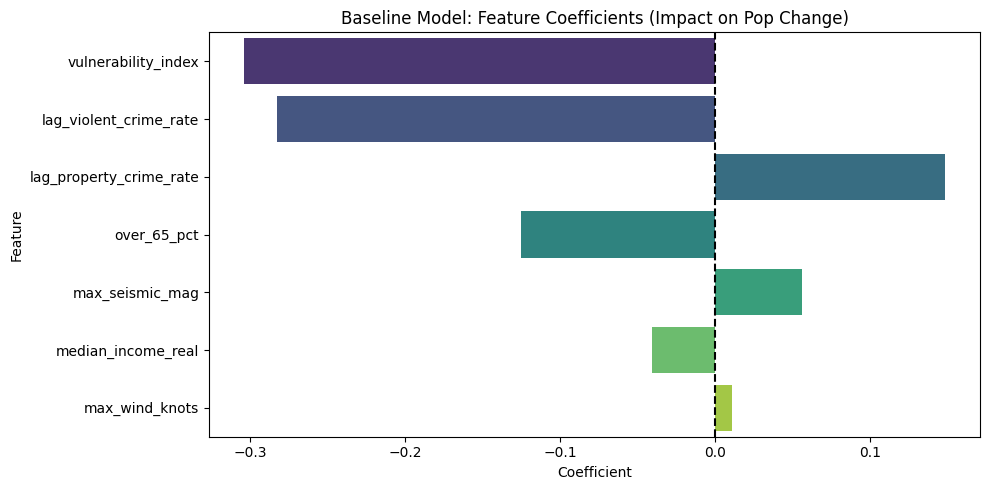

In [13]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Metrics
r2_base = r2_score(y_test, y_pred_baseline)
mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

# 2. Create a clean Summary Table
baseline_metrics_df = pd.DataFrame({
    'Metric': ['R-Squared (Explaining Variance)', 'Mean Absolute Error (Avg % Error)', 'Root Mean Squared Error'],
    'Value': [f"{r2_base:.4f}", f"{mae_base:.4f}%", f"{rmse_base:.4f}%"],
    'Context': ['This is our Phase 1 Baseline (Non-Leaked)', 'Target for improvement in Phase 2', 'Higher error expected in OLS']
})

print("--- PHASE 1: Baseline OLS Model Performance ---")
display(baseline_metrics_df)

# 3. Plot Feature Coefficients (Strategic Insight)
# *** UPDATED to include the 2 new crime features ***
final_features = [
    'vulnerability_index', 
    'median_income_real', 
    'over_65_pct', 
    'max_wind_knots', 
    'max_seismic_mag',
    'lag_violent_crime_rate',    # NEW
    'lag_property_crime_rate'    # NEW
]

coef_df = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis', hue='Feature', legend=False)
plt.title('Baseline Model: Feature Coefficients (Impact on Pop Change)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## 4. Phase 1: Conclusion & Baseline Verification

By establishing a non-leaked methodology, we have produced an academically honest benchmark for the project.

1. **Elimination of Data Leakage**: By fitting the PCA and Scaling parameters strictly on the training set, we ensure the evaluation metrics reflect the model's true predictive power on unseen data.
2. **Dimensionality Reduction**: The PCA successfully synthesized 15 socioeconomic variables into a single **Vulnerability Index**, mitigating multicollinearity while preserving the structural signal of risk.
3. **Mandate for Phase 2**: The baseline $R^2$ confirms that linear models struggle to capture the stochastic, non-linear nature of catastrophic shocks. This provides the technical justification for transitioning to **Random Forest** ensembles in Phase 2 to better capture the "tipping points" of migration.